---
Phase 2-6: 損失函數 + 優化器
---

損失函數：衡量「模型有多差」，數字越小越好
優化器：  決定「怎麼更新權重讓 Loss 變小」

本檔涵蓋：
  Part A: 損失函數（MSE / CE / BCE + NumPy 手刻）
  Part B: 優化器演進（SGD → Momentum → Adam + NumPy 手刻）
  Part C: 學習率的影響

In [1]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================================
# Part A: 損失函數
# ============================================================================

In [2]:
print("=" * 60)
print("Part A: 損失函數")
print("=" * 60)

# ─────────────────────────────────────────
# 1. MSE Loss（回歸用）
# ─────────────────────────────────────────
print("\n--- MSE (Mean Squared Error) ---")

# NumPy 手刻
y_true = np.array([3.0, 5.0, 2.5])
y_pred = np.array([2.8, 5.2, 2.0])
mse_np = np.mean((y_pred - y_true) ** 2)

# PyTorch
criterion_mse = nn.MSELoss()
mse_pt = criterion_mse(torch.tensor(y_pred), torch.tensor(y_true))

print(f"  NumPy MSE: {mse_np:.4f}")
print(f"  PyTorch:   {mse_pt.item():.4f}")
print(f"  公式: (1/N) Σ (ŷ - y)²")
print(f"  用途: 回歸問題（預測連續值）")

# ─────────────────────────────────────────
# 2. Cross-Entropy Loss（多類別分類用）
# ─────────────────────────────────────────
print("\n--- Cross-Entropy Loss ---")

# NumPy 手刻
logits = np.array([[2.0, 1.0, 0.1],        # 樣本 0
                   [0.5, 2.5, 0.3]])        # 樣本 1
targets = np.array([0, 1])                   # 正確類別

# 手算 Softmax + CE
def cross_entropy_numpy(logits, targets):
    # Softmax
    exp_l = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs = exp_l / exp_l.sum(axis=1, keepdims=True)
    # CE = -log(正確類別的機率)
    ce = -np.log(probs[np.arange(len(targets)), targets] + 1e-8)
    return ce.mean()

ce_np = cross_entropy_numpy(logits, targets)

# PyTorch（內建 Softmax，輸入是 logits 不是機率！）
criterion_ce = nn.CrossEntropyLoss()
ce_pt = criterion_ce(torch.tensor(logits), torch.tensor(targets))

print(f"  NumPy CE:  {ce_np:.4f}")
print(f"  PyTorch:   {ce_pt.item():.4f}")
print(f"  公式: -log(softmax(logits)[target])")
print(f"  重要: PyTorch 的 CrossEntropyLoss 接受 raw logits，不要先做 Softmax！")

# ─────────────────────────────────────────
# 3. BCE Loss（二元分類用）
# ─────────────────────────────────────────
print("\n--- Binary Cross-Entropy Loss ---")

probs_pred = np.array([0.9, 0.2, 0.7])     # 模型預測的機率
labels = np.array([1.0, 0.0, 1.0])          # 真實標籤

# NumPy
bce_np = -np.mean(labels * np.log(probs_pred + 1e-8) +
                   (1 - labels) * np.log(1 - probs_pred + 1e-8))

# PyTorch
criterion_bce = nn.BCELoss()
bce_pt = criterion_bce(torch.tensor(probs_pred), torch.tensor(labels))

print(f"  NumPy BCE: {bce_np:.4f}")
print(f"  PyTorch:   {bce_pt.item():.4f}")

print("""
  損失函數選擇：
    問題類型           損失函數              PyTorch
    ────────────────────────────────────────────────
    回歸              MSE / MAE / Huber     nn.MSELoss()
    多類別分類         Cross-Entropy         nn.CrossEntropyLoss()
    二元分類           Binary CE             nn.BCEWithLogitsLoss()
    多標籤分類         Binary CE (per-label) nn.BCEWithLogitsLoss()
""")

Part A: 損失函數

--- MSE (Mean Squared Error) ---
  NumPy MSE: 0.1100
  PyTorch:   0.1100
  公式: (1/N) Σ (ŷ - y)²
  用途: 回歸問題（預測連續值）

--- Cross-Entropy Loss ---
  NumPy CE:  0.3185
  PyTorch:   0.3185
  公式: -log(softmax(logits)[target])
  重要: PyTorch 的 CrossEntropyLoss 接受 raw logits，不要先做 Softmax！

--- Binary Cross-Entropy Loss ---
  NumPy BCE: 0.2284
  PyTorch:   0.2284

  損失函數選擇：
    問題類型           損失函數              PyTorch
    ────────────────────────────────────────────────
    回歸              MSE / MAE / Huber     nn.MSELoss()
    多類別分類         Cross-Entropy         nn.CrossEntropyLoss()
    二元分類           Binary CE             nn.BCEWithLogitsLoss()
    多標籤分類         Binary CE (per-label) nn.BCEWithLogitsLoss()



## Part B: 優化器

Part B: 優化器 — 從 SGD 到 Adam 的演進

優化器的演進：

  SGD:        w -= lr × grad             （最基本）
    ↓ 問題：下降方向震盪、收斂慢
  Momentum:   v = β×v + grad             （加動量，像球往下滾）
              w -= lr × v
    ↓ 問題：所有參數用同一個學習率
  Adam:       結合 Momentum + 自適應學習率  （最常用）
              每個參數有自己的有效學習率

  SGD (lr=0.001)           : 最終 x=0.3967, y=0.1544, loss=0.364887
  Momentum (lr=0.001)      : 最終 x=0.9632, y=0.9277, loss=0.001353
  Adam (lr=0.01)           : 最終 x=0.6656, y=0.4415, loss=0.112058


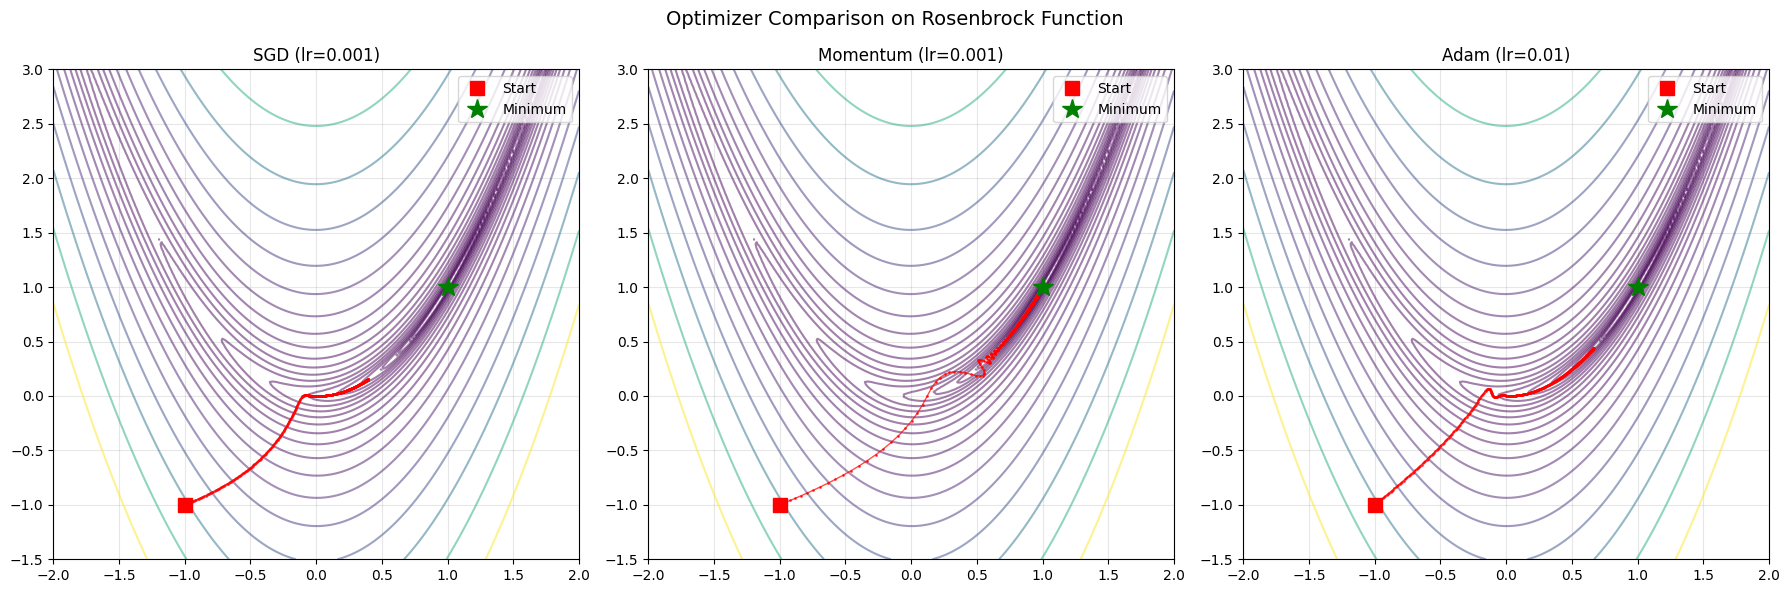

→ 圖表儲存至 plots/06_optimizer_comparison.png


In [3]:
print("=" * 60)
print("Part B: 優化器 — 從 SGD 到 Adam 的演進")
print("=" * 60)

print("""
優化器的演進：

  SGD:        w -= lr × grad             （最基本）
    ↓ 問題：下降方向震盪、收斂慢
  Momentum:   v = β×v + grad             （加動量，像球往下滾）
              w -= lr × v
    ↓ 問題：所有參數用同一個學習率
  Adam:       結合 Momentum + 自適應學習率  （最常用）
              每個參數有自己的有效學習率
""")

# ─────────────────────────────────────────
# NumPy 手刻三種優化器
# ─────────────────────────────────────────

# 目標函數：Rosenbrock (有名的難優化函數)
# f(x,y) = (1-x)² + 100(y-x²)²
def rosenbrock(params):
    x, y = params
    return (1 - x) ** 2 + 100 * (y - x ** 2) ** 2

def rosenbrock_grad(params):
    x, y = params
    dx = -2 * (1 - x) + 100 * 2 * (y - x ** 2) * (-2 * x)
    dy = 100 * 2 * (y - x ** 2)
    return np.array([dx, dy])


class SGD_Numpy:
    def __init__(self, lr=0.001):
        self.lr = lr

    def step(self, params, grads):
        return params - self.lr * grads


class Momentum_Numpy:
    def __init__(self, lr=0.001, beta=0.9):
        self.lr = lr
        self.beta = beta
        self.v = None

    def step(self, params, grads):
        if self.v is None:
            self.v = np.zeros_like(params)
        self.v = self.beta * self.v + grads
        return params - self.lr * self.v


class Adam_Numpy:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = None    # 一階動量 (平均梯度)
        self.v = None    # 二階動量 (平均梯度²)
        self.t = 0

    def step(self, params, grads):
        if self.m is None:
            self.m = np.zeros_like(params)
            self.v = np.zeros_like(params)
        self.t += 1

        # 更新動量
        self.m = self.beta1 * self.m + (1 - self.beta1) * grads
        self.v = self.beta2 * self.v + (1 - self.beta2) * grads ** 2

        # 偏差校正（初期 m 和 v 接近 0，需要校正）
        m_hat = self.m / (1 - self.beta1 ** self.t)
        v_hat = self.v / (1 - self.beta2 ** self.t)

        return params - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


# 跑三種優化器
optimizers = {
    'SGD (lr=0.001)': SGD_Numpy(lr=0.001),
    'Momentum (lr=0.001)': Momentum_Numpy(lr=0.001),
    'Adam (lr=0.01)': Adam_Numpy(lr=0.01),
}

paths = {}
for name, opt in optimizers.items():
    params = np.array([-1.0, -1.0])
    path = [params.copy()]

    for _ in range(500):
        grads = rosenbrock_grad(params)
        # 梯度裁剪（防止爆炸）
        grad_norm = np.linalg.norm(grads)
        if grad_norm > 10:
            grads = grads * 10 / grad_norm
        params = opt.step(params, grads)
        path.append(params.copy())

    paths[name] = np.array(path)
    final_loss = rosenbrock(params)
    print(f"  {name:25s}: 最終 x={params[0]:.4f}, y={params[1]:.4f}, "
          f"loss={final_loss:.6f}")

# 畫優化路徑
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
x_grid = np.linspace(-2, 2, 200)
y_grid = np.linspace(-1.5, 3, 200)
X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)
Z = (1 - X_mesh) ** 2 + 100 * (Y_mesh - X_mesh ** 2) ** 2

for ax, (name, path) in zip(axes, paths.items()):
    ax.contour(X_mesh, Y_mesh, Z, levels=np.logspace(-1, 3, 20), cmap='viridis', alpha=0.5)
    ax.plot(path[:, 0], path[:, 1], 'r.-', markersize=2, linewidth=1, alpha=0.7)
    ax.plot(path[0, 0], path[0, 1], 'rs', markersize=10, label='Start')
    ax.plot(1, 1, 'g*', markersize=15, label='Minimum')
    ax.set_title(name)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1.5, 3)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Optimizer Comparison on Rosenbrock Function', fontsize=14)
plt.tight_layout()
plt.savefig('phase-2-deep-learning/plots/06_optimizer_comparison.png', dpi=100)
plt.show()
print("→ 圖表儲存至 plots/06_optimizer_comparison.png")

## Part B.2: PyTorch 優化器

In [4]:
print("\n--- PyTorch 優化器用法 ---")

model = nn.Linear(10, 3)

# 常用優化器
opt_sgd     = torch.optim.SGD(model.parameters(), lr=0.01)
opt_mom     = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
opt_adam    = torch.optim.Adam(model.parameters(), lr=0.001)
opt_adamw   = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

print("""
PyTorch 常用優化器：

  優化器                      適用場景
  ──────────────────────────────────────────
  SGD(lr, momentum=0.9)     CV 模型（ResNet 常用 SGD+Momentum）
  Adam(lr=0.001)            NLP / 快速實驗 / 大多數場景
  AdamW(lr, weight_decay)   Transformer / LLM（Adam + L2 正則化）

  Adam 是預設首選。不知道選什麼就用 Adam。
  AdamW 在 Transformer 中表現更好（正確的 weight decay 實作）。
""")


--- PyTorch 優化器用法 ---



PyTorch 常用優化器：

  優化器                      適用場景
  ──────────────────────────────────────────
  SGD(lr, momentum=0.9)     CV 模型（ResNet 常用 SGD+Momentum）
  Adam(lr=0.001)            NLP / 快速實驗 / 大多數場景
  AdamW(lr, weight_decay)   Transformer / LLM（Adam + L2 正則化）

  Adam 是預設首選。不知道選什麼就用 Adam。
  AdamW 在 Transformer 中表現更好（正確的 weight decay 實作）。



## Part C: 學習率的影響

Part C: 學習率的影響


  lr=0.0001   → Final Loss=1.8627, Test Acc=66.11%
  lr=0.001    → Final Loss=0.1841, Test Acc=95.56%


  lr=0.01     → Final Loss=0.0012, Test Acc=97.50%


  lr=0.1      → Final Loss=0.0000, Test Acc=96.11%
  lr=1.0      → Final Loss=0.0000, Test Acc=96.39%


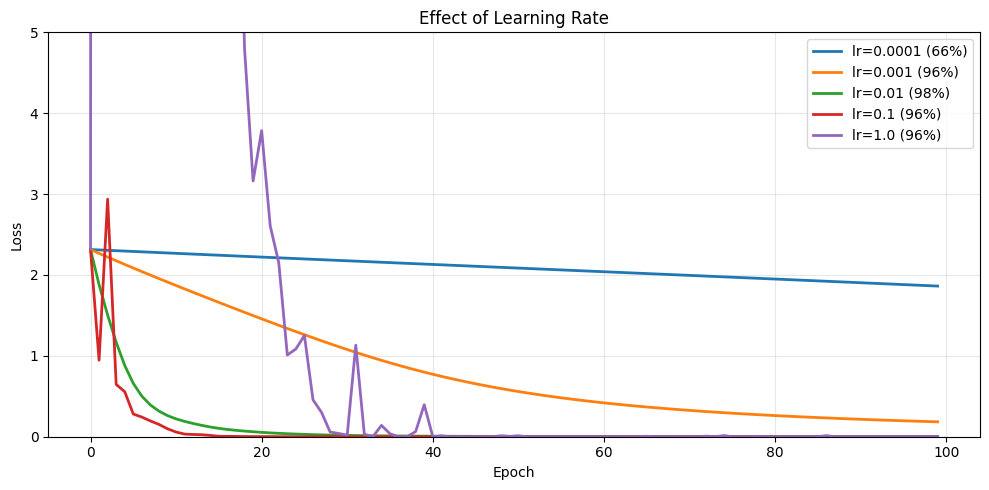

→ 圖表儲存至 plots/06_learning_rate.png


In [5]:
print("=" * 60)
print("Part C: 學習率的影響")
print("=" * 60)

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

digits = load_digits()
scaler = StandardScaler()
X = torch.tensor(scaler.fit_transform(digits.data), dtype=torch.float32)
y = torch.tensor(digits.target, dtype=torch.long)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0]
lr_results = {}

for lr in learning_rates:
    torch.manual_seed(42)
    model = nn.Sequential(nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, 10))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    losses = []
    for epoch in range(100):
        logits = model(X_tr)
        loss = criterion(logits, y_tr)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    with torch.no_grad():
        acc = (model(X_te).argmax(1) == y_te).float().mean().item()
    lr_results[lr] = {'losses': losses, 'acc': acc}
    print(f"  lr={lr:<8} → Final Loss={losses[-1]:.4f}, Test Acc={acc:.2%}")

plt.figure(figsize=(10, 5))
for lr, data in lr_results.items():
    plt.plot(data['losses'], label=f"lr={lr} ({data['acc']:.0%})", linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Effect of Learning Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig('phase-2-deep-learning/plots/06_learning_rate.png', dpi=100)
plt.show()
print("→ 圖表儲存至 plots/06_learning_rate.png")

## 小結

In [6]:
print("\n" + "=" * 60)
print("小結")
print("=" * 60)
print("""
損失函數 + 優化器的選擇：

  任務          Loss                    Optimizer         LR
  ─────────────────────────────────────────────────────────
  分類          CrossEntropyLoss        Adam / AdamW      1e-3 ~ 1e-4
  回歸          MSELoss                 Adam              1e-3
  二元分類      BCEWithLogitsLoss       Adam              1e-3
  Transformer   CrossEntropyLoss        AdamW             1e-4 ~ 5e-5
  CNN (CV)      CrossEntropyLoss        SGD+Momentum      0.01 ~ 0.1

  不確定就用：Adam + lr=0.001，大部分情況都能跑。

下一步：07_training_loop.py — 完整訓練 MNIST
""")


小結

損失函數 + 優化器的選擇：

  任務          Loss                    Optimizer         LR
  ─────────────────────────────────────────────────────────
  分類          CrossEntropyLoss        Adam / AdamW      1e-3 ~ 1e-4
  回歸          MSELoss                 Adam              1e-3
  二元分類      BCEWithLogitsLoss       Adam              1e-3
  Transformer   CrossEntropyLoss        AdamW             1e-4 ~ 5e-5
  CNN (CV)      CrossEntropyLoss        SGD+Momentum      0.01 ~ 0.1

  不確定就用：Adam + lr=0.001，大部分情況都能跑。

下一步：07_training_loop.py — 完整訓練 MNIST

